In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from statsmodels.graphics.mosaicplot import mosaic

In [2]:
medical_data = pd.read_csv("medical_clean.csv")
df = medical_data
df.shape

(10000, 50)

In [3]:
#First Step Cleaning Data

In [4]:
#Replace categorical variables
df['Anxiety'] = df['Anxiety'].replace({1: 'Yes', 0: 'No'})
df['Overweight'] = df['Overweight'].replace({1: 'Yes', 0: 'No'})
# Fill NA Categorical Columns with mode
df['Anxiety'] = df['Anxiety'].fillna(df['Anxiety'].mode()[0])
df['Soft_drink'] = df['Soft_drink'].fillna(df['Soft_drink'].mode()[0])
df['Overweight'] = df['Overweight'].fillna(df['Overweight'].mode()[0])
df['HighBlood'] = df['HighBlood'].fillna(df['HighBlood'].mode()[0])
df['Stroke'] = df['Stroke'].fillna(df['Stroke'].mode()[0])
df['Arthritis'] = df['Arthritis'].fillna(df['Arthritis'].mode()[0])
df['Diabetes'] = df['Diabetes'].fillna(df['Diabetes'].mode()[0])
df['Hyperlipidemia'] = df['Hyperlipidemia'].fillna(df['Hyperlipidemia'].mode()[0])
df['Allergic_rhinitis'] = df['Allergic_rhinitis'].fillna(df['Allergic_rhinitis'].mode()[0])
df['Reflux_esophagitis'] = df['Reflux_esophagitis'].fillna(df['Reflux_esophagitis'].mode()[0])
df['Asthma'] = df['Asthma'].fillna(df['Asthma'].mode()[0])
# Fill NA Categorical Columns with median
df['Income'] = df['Income'].fillna(df['Income'].median()) 
df['Children'] = df['Children'].fillna(df['Children'].median())
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Lat'] = df['Lat'].fillna(df['Lat'].median())
df['Lng'] = df['Lng'].fillna(df['Lng'].median())
df['Population'] = df['Population'].fillna(df['Population'].median())
df['VitD_levels'] = df['VitD_levels'].fillna(df['VitD_levels'].median())
df['Doc_visits'] = df['Doc_visits'].fillna(df['Doc_visits'].median())
df['Full_meals_eaten'] = df['Full_meals_eaten'].fillna(df['Full_meals_eaten'].median())
df['Initial_days'] = df['Initial_days'].fillna(df['Initial_days'].median())
df['TotalCharge'] = df['TotalCharge'].fillna(df['TotalCharge'].median())
df['Additional_charges'] = df['Additional_charges'].fillna(df['Additional_charges'].median())
df['vitD_supp'] = df['vitD_supp'].fillna(df['vitD_supp'].median())

# Check for missing values
missing_values_count = df.isnull().sum()
print(missing_values_count)

# Convert specific columns to categorical
df["Item1"] = df["Item1"].astype("category")
df["Item2"] = df["Item2"].astype("category")
df["Item3"] = df["Item3"].astype("category")
df["Item4"] = df["Item4"].astype("category")
df["Item5"] = df["Item5"].astype("category")
df["Item6"] = df["Item6"].astype("category")
df["Item7"] = df["Item7"].astype("category")
df["Item8"] = df["Item8"].astype("category")

# Rename a few columns
df.rename({"Item1": "Timely_admission"}, axis="columns", inplace=True)
df.rename({"Item2": "Timely_treatment"}, axis="columns", inplace=True)
df.rename({"Item3": "Timely_visits"}, axis="columns", inplace=True)
df.rename({"Item4": "Reliability"}, axis="columns", inplace=True)
df.rename({"Item5": "Options"}, axis="columns", inplace=True)
df.rename({"Item6": "Hours_of_treatment"}, axis="columns", inplace=True)
df.rename({"Item7": "Courteous_staff"}, axis="columns", inplace=True)
df.rename({"Item8": "Active_Listening_Doctor"}, axis="columns", inplace=True)
df.rename({"TotalCharge": "DailyCharge"}, axis="columns", inplace=True)
df.rename({"Lat": "Latitude"}, axis="columns", inplace=True)
df.rename({"Lng": "Longitude"}, axis="columns", inplace=True)

CaseOrder             0
Customer_id           0
Interaction           0
UID                   0
City                  0
State                 0
County                0
Zip                   0
Lat                   0
Lng                   0
Population            0
Area                  0
TimeZone              0
Job                   0
Children              0
Age                   0
Income                0
Marital               0
Gender                0
ReAdmis               0
VitD_levels           0
Doc_visits            0
Full_meals_eaten      0
vitD_supp             0
Soft_drink            0
Initial_admin         0
HighBlood             0
Stroke                0
Complication_risk     0
Overweight            0
Arthritis             0
Diabetes              0
Hyperlipidemia        0
BackPain              0
Anxiety               0
Allergic_rhinitis     0
Reflux_esophagitis    0
Asthma                0
Services              0
Initial_days          0
TotalCharge           0
Additional_charg

In [5]:
def rep_outliers(df, columns):
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - (1.5 * IQR)
        upper_bound = Q3 + (1.5 * IQR)
        
        # Replacing outliers with the median
        median = df[col].median()
        df[col] = df[col].apply(lambda x: median if x < lower_bound or x > upper_bound else x)
    return df

In [6]:
outlier_columns = ['Latitude', 'Longitude', 'Population', 'Children', 'Age', 'Income', 'VitD_levels', 'Doc_visits', 'Full_meals_eaten', 'vitD_supp', 'Initial_days', 'DailyCharge', 'Additional_charges']
df = rep_outliers(df, outlier_columns)

In [7]:
df[outlier_columns].describe()

,Latitude,Longitude,Population,Children,Age,Income,VitD_levels,Doc_visits,Full_meals_eaten,vitD_supp,Initial_days,DailyCharge,Additional_charges
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,38.752350,-90.086857,6067.998300,1.779900,53.511700,37355.193095,17.960411,5.012200,0.997200,0.377200,34.455299,5312.172769,12224.131644
std,4.731417,13.175417,8154.065271,1.673361,20.638538,22986.930317,1.960102,1.045734,0.997041,0.586306,26.309341,2180.393838,5683.843249
min,25.701180,-122.720600,0.000000,0.000000,18.000000,154.080000,12.546070,1.000000,0.000000,0.000000,1.001981,1938.312067,3125.703000
25%,35.421360,-96.563192,694.750000,0.000000,36.000000,19598.775000,16.645650,4.000000,0.000000,0.000000,7.896215,3179.374015,7986.487755
50%,39.419355,-88.396225,2767.000000,1.000000,53.000000,33766.005000,17.951122,5.000000,1.000000,0.000000,35.836244,5213.952000,11573.938868
75%,41.966773,-80.438050,7813.250000,3.000000,71.000000,51024.942500,19.325515,6.000000,2.000000,1.000000,61.161020,7459.699750,14654.504410
max,48.988170,-65.290170,33806.000000,7.000000,89.000000,106220.500000,23.363658,9.000000,5.000000,2.000000,71.981490,9180.728000,27059.629700


In [8]:
# Change datatypes
df = df.astype({
    'Anxiety': 'category',
    'Overweight': 'category',
    'Children': 'category',
    'vitD_supp': 'category',
    'UID': 'str',
    'Interaction': 'str',
    'Zip': 'str',
    'Latitude': 'int64',
    'Longitude': 'int64',
    'VitD_levels': 'int64',
    'DailyCharge': 'int64',
    'Additional_charges': 'int64',
    'Income': 'int64',
    'Initial_days': 'int64'
})

# Rename a few columns
df.rename({"CaseOrder": "Patient_Num"}, axis="columns", inplace=True)
df.rename({"A": "CaseOrder"}, axis="columns", inplace=True)

# Round daily charge and additional charges to no decimal points
df["Additional_charges"] = df["Additional_charges"].round(0)
df["DailyCharge"] = df["DailyCharge"].round(0)

# Check dataframe info
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 50 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   Patient_Num              10000 non-null  int64   
 1   Customer_id              10000 non-null  object  
 2   Interaction              10000 non-null  object  
 3   UID                      10000 non-null  object  
 4   City                     10000 non-null  object  
 5   State                    10000 non-null  object  
 6   County                   10000 non-null  object  
 7   Zip                      10000 non-null  object  
 8   Latitude                 10000 non-null  int64   
 9   Longitude                10000 non-null  int64   
 10  Population               10000 non-null  float64 
 11  Area                     10000 non-null  object  
 12  TimeZone                 10000 non-null  object  
 13  Job                      10000 non-null  object  
 14  Childre

In [9]:
#Data Analysis-Chi-square
import scipy.stats as st
from scipy.stats import chi2_contingency

In [10]:
#Chi square test
contingency_table = pd.crosstab(df.Timely_admission, df.Timely_treatment)
chi2, p, dof, expected = chi2_contingency(contingency_table)
print(contingency_table)

Timely_treatment    1    2     3     4    5    6  7
Timely_admission                                   
1                  65  113    31     4    0    0  0
2                 120  551   552    88    4    0  0
3                  25  571  1658  1024  126    0  0
4                   3  119  1069  1635  602   27  0
5                   0    6   128   560  579  101  3
6                   0    0     1    40  106   72  6
7                   0    0     0     0    4    3  3
8                   0    0     0     0    0    1  0


In [11]:
chi_analysis = st.chi2_contingency(contingency_table)
print(chi_analysis)

Chi2ContingencyResult(statistic=7637.372537949044, pvalue=0.0, dof=42, expected_freq=array([[4.5369000e+00, 2.8968000e+01, 7.3250700e+01, 7.1376300e+01,
        3.0267300e+01, 4.3452000e+00, 2.5560000e-01],
       [2.8009500e+01, 1.7884000e+02, 4.5222850e+02, 4.4065650e+02,
        1.8686150e+02, 2.6826000e+01, 1.5780000e+00],
       [7.2505200e+01, 4.6294400e+02, 1.1706356e+03, 1.1406804e+03,
        4.8370840e+02, 6.9441600e+01, 4.0848000e+00],
       [7.3591500e+01, 4.6988000e+02, 1.1881745e+03, 1.1577705e+03,
        4.9095550e+02, 7.0482000e+01, 4.1460000e+00],
       [2.9330100e+01, 1.8727200e+02, 4.7355030e+02, 4.6143270e+02,
        1.9567170e+02, 2.8090800e+01, 1.6524000e+00],
       [4.7925000e+00, 3.0600000e+01, 7.7377500e+01, 7.5397500e+01,
        3.1972500e+01, 4.5900000e+00, 2.7000000e-01],
       [2.1300000e-01, 1.3600000e+00, 3.4390000e+00, 3.3510000e+00,
        1.4210000e+00, 2.0400000e-01, 1.2000000e-02],
       [2.1300000e-02, 1.3600000e-01, 3.4390000e-01, 3.351000

In [12]:
alpha = 0.05
if p < alpha:
    print("There is a signifcant association between the variables.")
else:
    print("There is no signifcant association between the variables.")

There is a signifcant association between the variables.


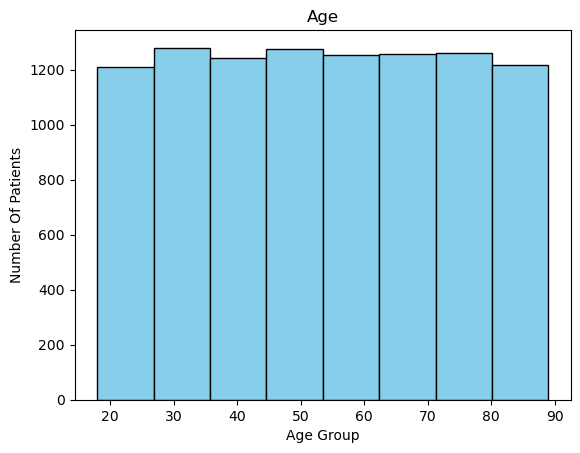

<Axes: title={'center': 'Income'}, xlabel='Income', ylabel='Number Of Patients'>

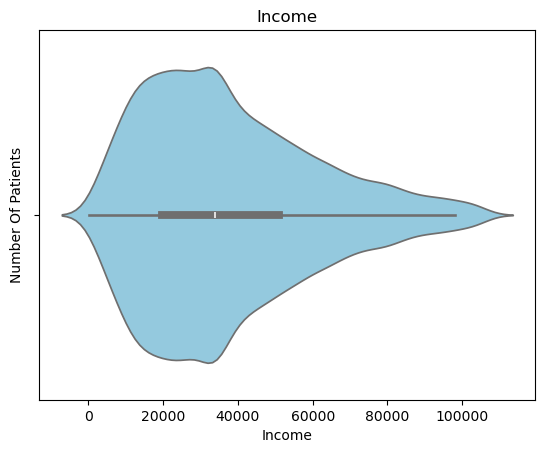

In [13]:
#Identify the distribution of two continuous variables  Histogram and violin plot
data = df.Age
plt.xlabel('Age Group')
plt.ylabel('Number Of Patients')
plt.title('Age')
plt.hist(data, bins = 8, color='skyblue', edgecolor='black')
plt.show()

plt.xlabel("Income")
plt.ylabel("Number Of Patients")
plt.title("Income")
sns.violinplot(data=df, x="Income", color="skyblue", inner="box")

In [14]:
#After removing the outliers the groups looks to be well balanced for the demographics
#The Income is showing a greater amount of patients earning low incomes

In [15]:
#describe for age & income
df.Age.describe()

count    10000.000000
mean        53.511700
std         20.638538
min         18.000000
25%         36.000000
50%         53.000000
75%         71.000000
max         89.000000
Name: Age, dtype: float64

In [16]:
df.Income.describe()

count     10000.000000
mean      37354.702200
std       22986.927942
min         154.000000
25%       19598.250000
50%       33765.500000
75%       51024.750000
max      106220.000000
Name: Income, dtype: float64

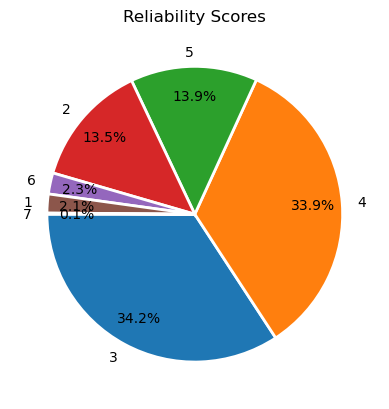

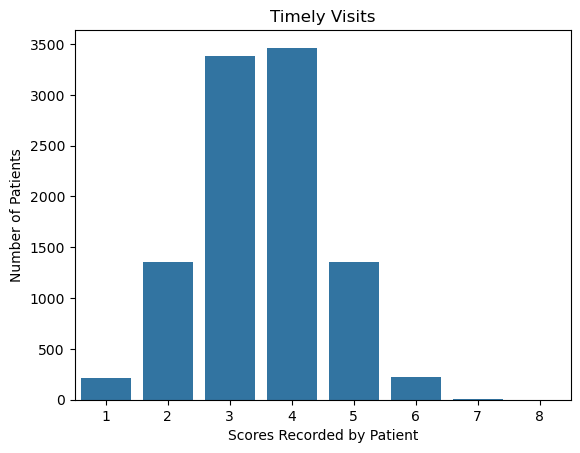

In [17]:
#two categorical variables using univariate statistics Pie chart 
plt.xlabel('')
plt.ylabel('')
plt.title('Reliability Scores')
Labels= [1,2,3,4,5,6,7,8]
y = df["Reliability"].value_counts()
wp = {'linewidth': 2.0, 'edgecolor':'white'}
plt.pie(y, labels=y.index,startangle=180, labeldistance= 1.1, pctdistance=0.8, autopct='%1.1f%%', wedgeprops=wp )
plt.show()

TimelyV = df.Timely_visits
sns.countplot(x=TimelyV)
plt.title("Timely Visits")
plt.ylabel('Number of Patients')
plt.xlabel('Scores Recorded by Patient')
plt.show()

In [18]:
# Most of the patients seem to score the reliability of the hospital at a 3 or 4 indicating the high to medium importance of this factor
# Most of the patients seem to score the timely visits of the hospital at a 3 or 4 indicating the high to medium importance of this factor

In [19]:
#describe for reliability & timely admission
df.Reliability.value_counts()

Reliability
3    3422
4    3394
5    1388
2    1346
6     231
1     207
7      12
Name: count, dtype: int64

In [20]:
df.Timely_admission.value_counts()

Timely_admission
4    3455
3    3404
5    1377
2    1315
6     225
1     213
7      10
8       1
Name: count, dtype: int64

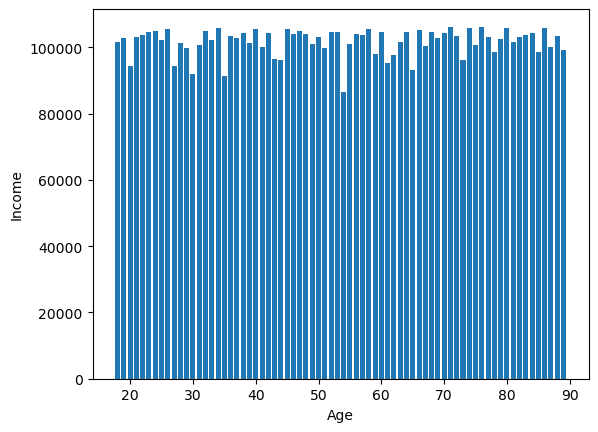

In [21]:
#Identify the distribution of two continuous variables Crosschart/stacked bar chart
Age = df.Age
Income = df.Income
plt.bar(Age,Income)
plt.xlabel('Age')
plt.ylabel('Income')
plt.show()

In [22]:
#This chart shows in depth that the demographics of the participants have various ages and salaries when compared side by side

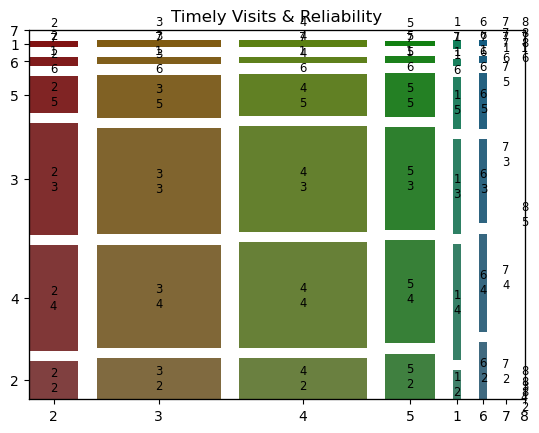

In [23]:
#two categorical variables Mosaic plot
from statsmodels.graphics.mosaicplot import mosaic
mosaic(df, ['Timely_visits', 'Reliability'],  gap=0.05, title='Timely Visits & Reliability')
plt.show()

In [24]:
#This chart is looking at occurrence and relationship simultaneously, This shows that most people seem to find timely visits and reliability as important factors and those most of those who find them important also share the same view coincidingly for these two factors 

In [25]:
df.Timely_visits.value_counts()

Timely_visits
4    3464
3    3379
5    1358
2    1356
6     220
1     211
7      11
8       1
Name: count, dtype: int64